# Notebook 01 — Exploratory Data Analysis

Explore both datasets before any preprocessing.

In [1]:
import sys; sys.path.insert(0, '..')
import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from collections import Counter
from sklearn.datasets import fetch_20newsgroups


## 1. 20 Newsgroups Dataset

In [2]:
news = fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'), random_state=42)
texts_ng, labels_ng, names_ng = news.data, news.target, news.target_names
print(f"Documents : {len(texts_ng):,}")
print(f"Categories: {len(names_ng)}")
print(f"\nCategory list:")
for i, n in enumerate(names_ng):
    cnt = int((np.array(labels_ng) == i).sum())
    print(f"  {i:2d}. {n:<35s} {cnt:4d} docs")


Documents : 18,846
Categories: 20

Category list:
   0. alt.atheism                          799 docs
   1. comp.graphics                        973 docs
   2. comp.os.ms-windows.misc              985 docs
   3. comp.sys.ibm.pc.hardware             982 docs
   4. comp.sys.mac.hardware                963 docs
   5. comp.windows.x                       988 docs
   6. misc.forsale                         975 docs
   7. rec.autos                            990 docs
   8. rec.motorcycles                      996 docs
   9. rec.sport.baseball                   994 docs
  10. rec.sport.hockey                     999 docs
  11. sci.crypt                            991 docs
  12. sci.electronics                      984 docs
  13. sci.med                              990 docs
  14. sci.space                            987 docs
  15. soc.religion.christian               997 docs
  16. talk.politics.guns                   910 docs
  17. talk.politics.mideast                940 docs
  18. talk.pol

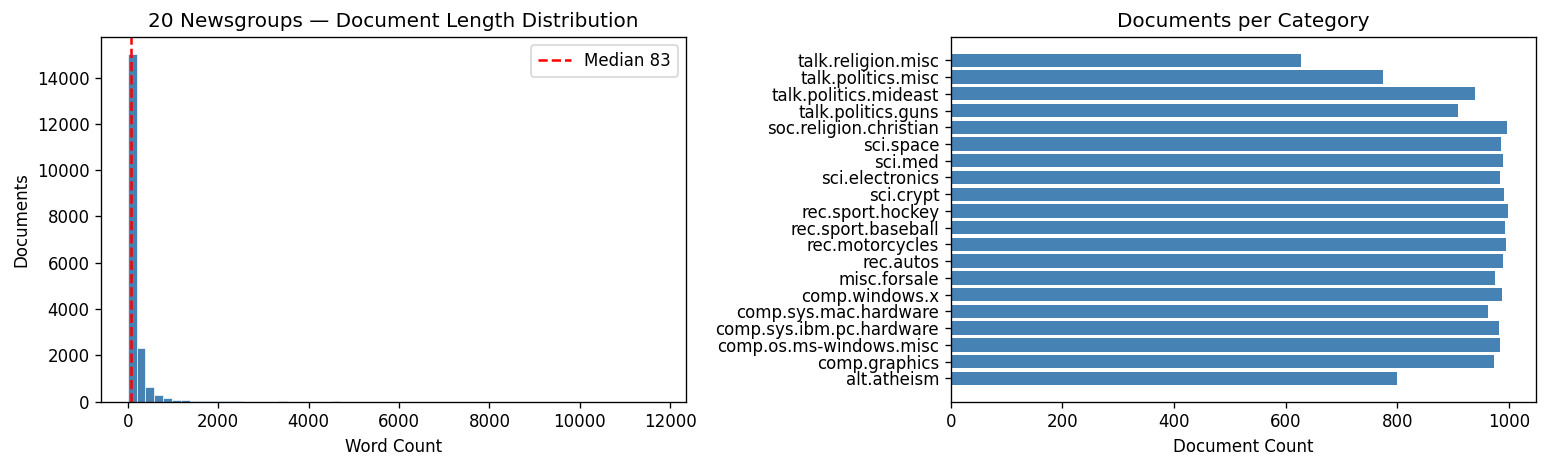

Median length: 83 words | Mean: 182 | Max: 11,765


In [3]:
# Document length distribution
lengths_ng = [len(t.split()) for t in texts_ng]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(lengths_ng, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Word Count'); axes[0].set_ylabel('Documents')
axes[0].set_title('20 Newsgroups — Document Length Distribution')
axes[0].axvline(np.median(lengths_ng), color='red', linestyle='--', label=f'Median {np.median(lengths_ng):.0f}')
axes[0].legend()
# Category sizes
cat_counts = Counter(labels_ng)
cats = [names_ng[i] for i in sorted(cat_counts)]
counts = [cat_counts[i] for i in sorted(cat_counts)]
axes[1].barh(cats, counts, color='steelblue')
axes[1].set_xlabel('Document Count')
axes[1].set_title('Documents per Category')
plt.tight_layout(); plt.savefig('../outputs/figures/eda_newsgroups.png', bbox_inches='tight'); plt.show()
print(f"Median length: {np.median(lengths_ng):.0f} words | Mean: {np.mean(lengths_ng):.0f} | Max: {max(lengths_ng):,}")


/var/folders/dq/z6s2pg5d6m559mffmf2511hr0000gn/T/ipykernel_39631/1463681203.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(words, rotation=60, ha='right')


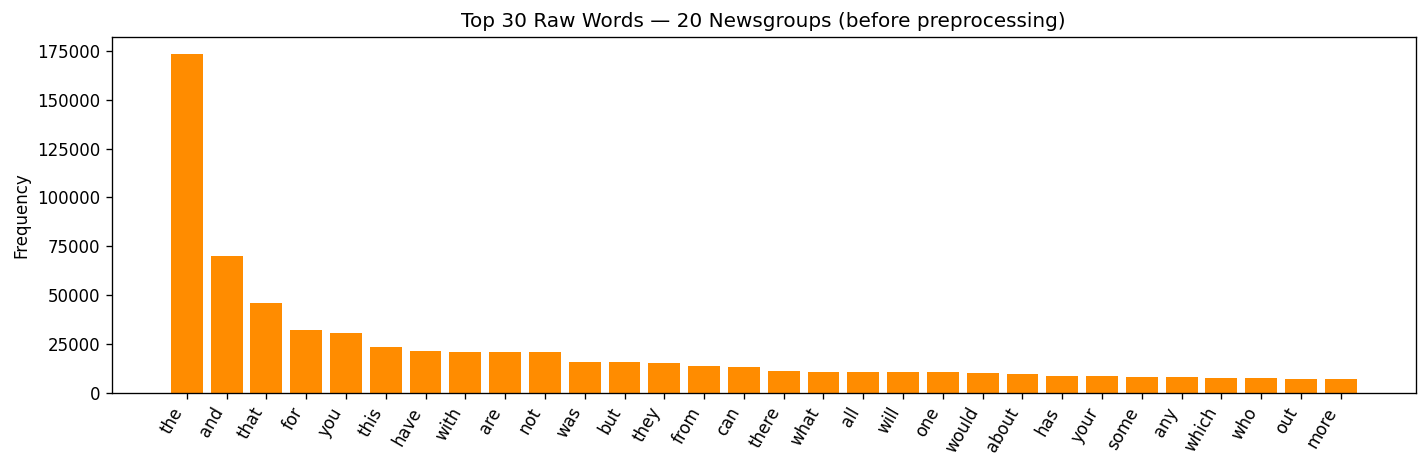

In [4]:
# Top word frequencies (raw)
from collections import Counter
import re
all_words = re.findall(r'\b[a-z]{3,}\b', ' '.join(texts_ng).lower())
top50 = Counter(all_words).most_common(30)
words, freqs = zip(*top50)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(words, freqs, color='darkorange')
ax.set_xticklabels(words, rotation=60, ha='right')
ax.set_title('Top 30 Raw Words — 20 Newsgroups (before preprocessing)')
ax.set_ylabel('Frequency')
plt.tight_layout(); plt.savefig('../outputs/figures/eda_top_words_newsgroups.png', bbox_inches='tight'); plt.show()


## 2. Wikipedia People Dataset

In [5]:
df_wiki = pd.read_csv('../data/raw/people_wiki.csv')
print(f"Articles  : {len(df_wiki):,}")
print(f"Columns   : {list(df_wiki.columns)}")
print(f"Null texts: {df_wiki['text'].isna().sum()}")
print("\nSample names:")
print(df_wiki['name'].head(10).tolist())


Articles  : 538
Columns   : ['uri', 'name', 'text']
Null texts: 0

Sample names:
['Albert Einstein', 'Isaac Newton', 'Marie Curie', 'Charles Darwin', 'Stephen Hawking', 'Nikola Tesla', 'Richard Feynman', 'Carl Sagan', 'Galileo Galilei', 'Max Planck']


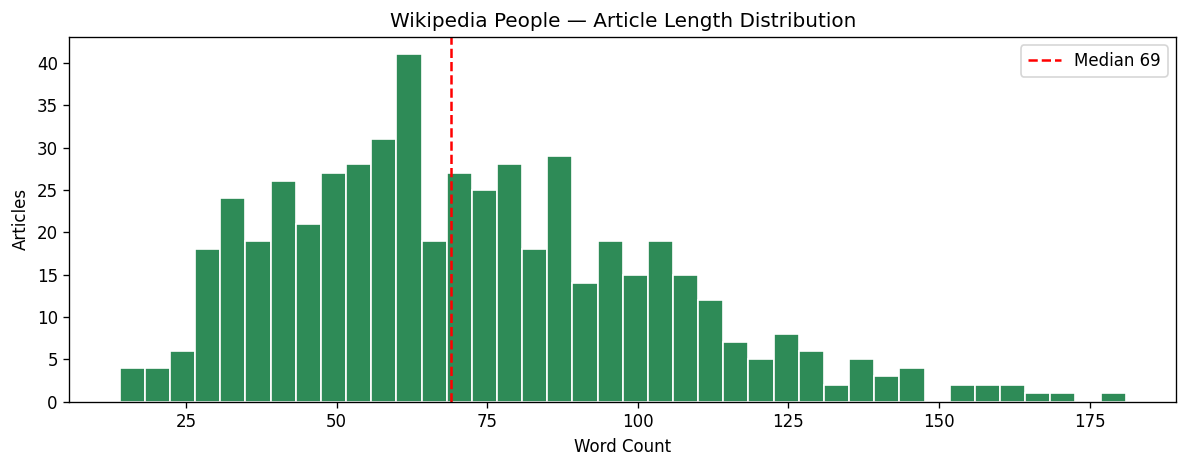

Median: 69 | Mean: 72 | Max: 181


In [6]:
lengths_wiki = df_wiki['text'].str.split().str.len().fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths_wiki, bins=40, color='seagreen', edgecolor='white')
ax.axvline(lengths_wiki.median(), color='red', linestyle='--', label=f'Median {lengths_wiki.median():.0f}')
ax.set_xlabel('Word Count'); ax.set_ylabel('Articles')
ax.set_title('Wikipedia People — Article Length Distribution')
ax.legend()
plt.tight_layout(); plt.savefig('../outputs/figures/eda_wikipedia.png', bbox_inches='tight'); plt.show()
print(f"Median: {lengths_wiki.median():.0f} | Mean: {lengths_wiki.mean():.0f} | Max: {lengths_wiki.max()}")


In [7]:
# Show sample articles
for _, row in df_wiki.sample(3, random_state=42).iterrows():
    print(f"NAME: {row['name']}")
    print(f"TEXT: {row['text'][:300]}...")
    print()


NAME: Humphrey Bogart
TEXT: Humphrey DeForest Bogart, nicknamed Bogie, was an American actor. His performances in classic Hollywood cinema made him an American cultural icon. In 1999, the American Film Institute selected Bogart as the greatest male star of classic American cinema....

NAME: William James
TEXT: William James was an American philosopher and psychologist. The first educator to offer a psychology course in the United States, he is considered to be one of the leading thinkers of the late 19th century, one of the most influential philosophers and is often dubbed the "father of American psycholo...

NAME: Hank Aaron
TEXT: Henry Louis Aaron, nicknamed "Hammer" or "Hammerin' Hank", was an American professional baseball right fielder who played 23 seasons in Major League Baseball (MLB), from 1954 through 1976. Considered one of the greatest baseball players in history, he spent 21 seasons with the Milwaukee / Atlanta Br...



## 3. Dataset Comparison Summary

In [8]:
summary = pd.DataFrame({
    'Dataset': ['20 Newsgroups', 'Wikipedia People'],
    'Documents': [len(texts_ng), len(df_wiki)],
    'Categories': [len(names_ng), 'N/A (biographical)'],
    'Median Doc Length': [np.median(lengths_ng), lengths_wiki.median()],
    'Mean Doc Length': [np.mean(lengths_ng), lengths_wiki.mean()],
})
print(summary.to_string(index=False))


         Dataset  Documents         Categories  Median Doc Length  Mean Doc Length
   20 Newsgroups      18846                 20               83.0       181.637748
Wikipedia People        538 N/A (biographical)               69.0        72.286245
